In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df = pd.read_excel("glass.xlsx",sheet_name="glass")

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


#Dataset Information

Display the shape, data types, and summary statistics of the dataset.

In [14]:
df.shape
print(df.shape)
df.info()
df.describe()

(214, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


#Missing Values
Check whether the dataset contains any missing values.

In [10]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

#Duplicate Values

Check whether duplicate records are present in the dataset.

In [11]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.drop_duplicates()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


#Histogram

Visualize the distribution of numerical features using histograms.

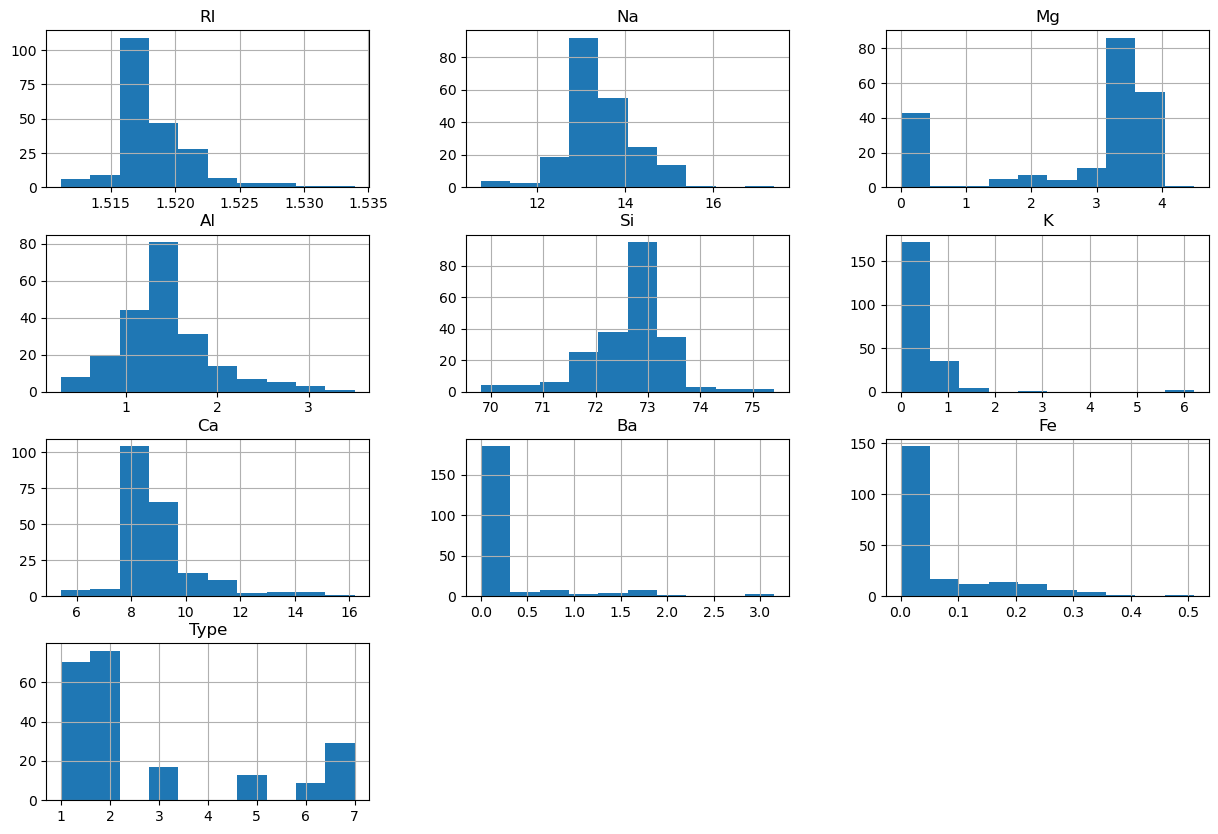

In [16]:
df.hist(figsize=(15,10))

plt.show()

#Box Plot

Visualize outliers using box plots.

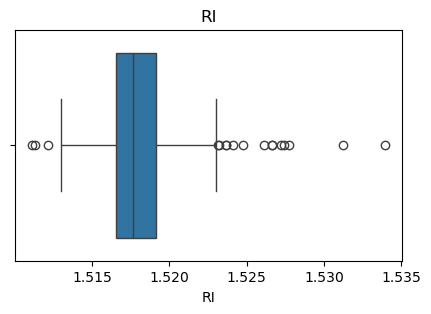

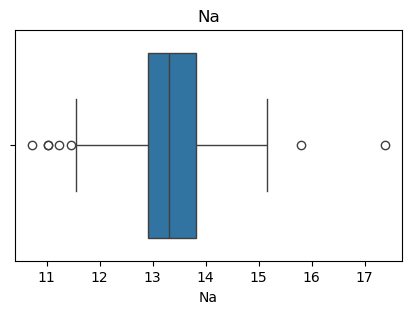

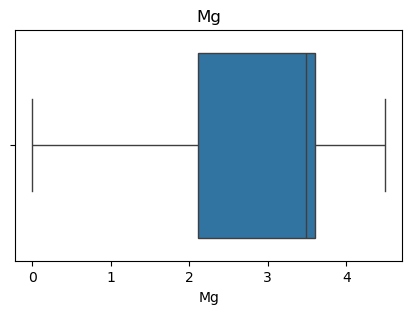

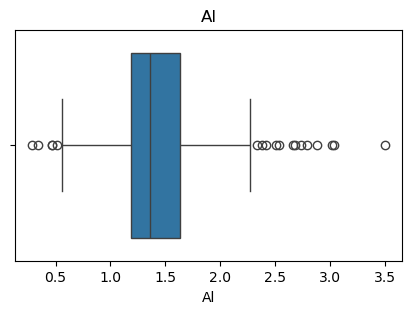

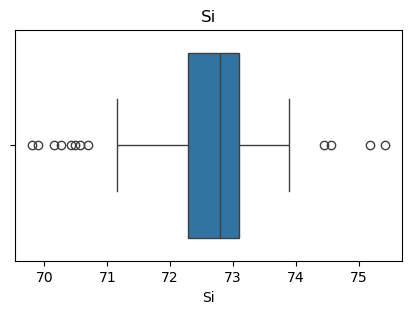

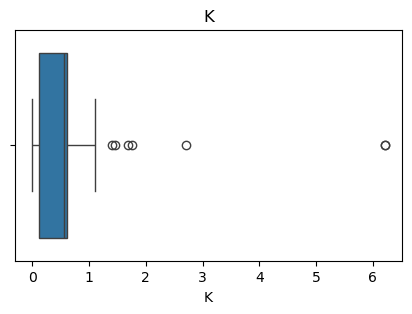

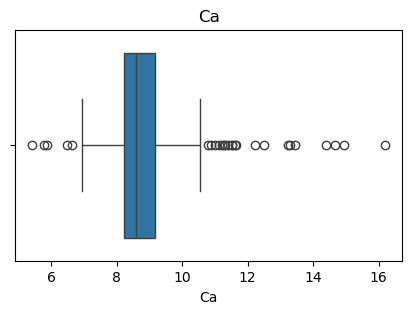

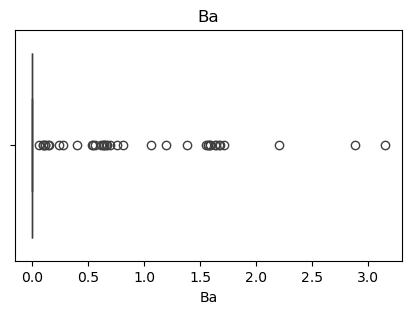

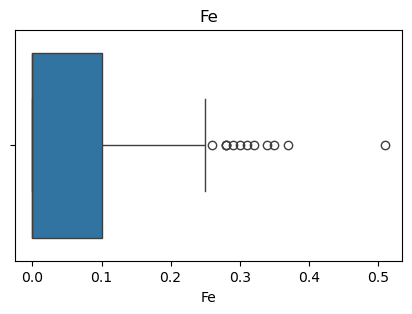

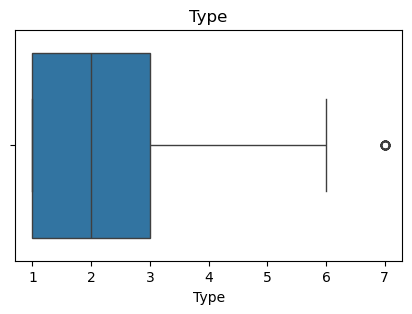

In [17]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#Remove Outliers

Use the IQR method to remove outliers from the numerical features.

In [21]:
df_original = df.copy()

num_cols = df.select_dtypes(include=['int64','float64']).columns

# Exclude the target column if its name is 'Type'
if 'Type' in num_cols:
    num_cols = num_cols.drop('Type')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(df.shape)

(59, 10)


#Correlation Matrix

Visualize the relationships among numerical features using a correlation heatmap.

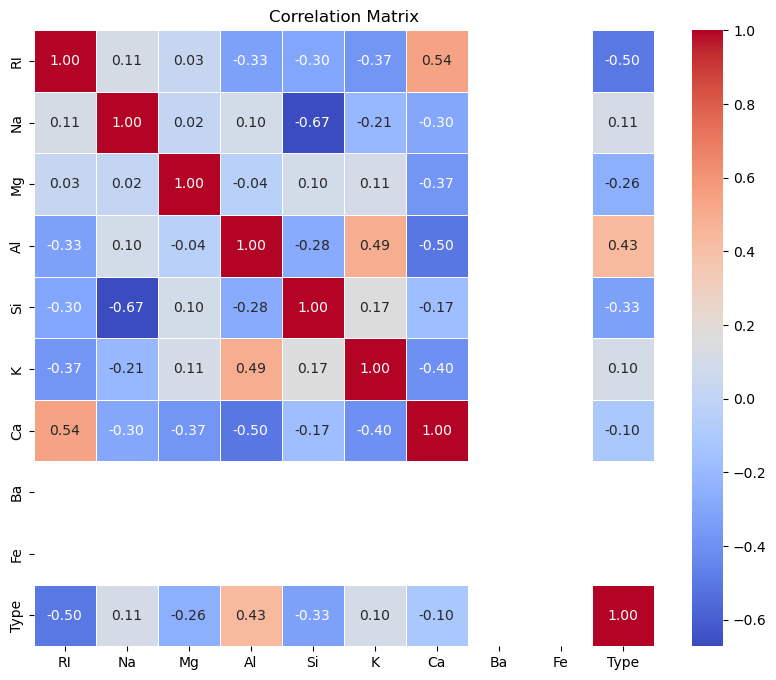

In [24]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

#Data Preprocessing

Preprocessing is performed to prepare the dataset for machine learning. This includes handling missing values, encoding categorical variables, feature scaling, and balancing the dataset.

#Missing Value Handling

Check whether the dataset contains missing values. If missing values are present, they can be removed or imputed.

In [25]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

#Encoding

Check whether the dataset contains categorical features. If categorical variables are present, apply encoding techniques such as One-Hot Encoding or Label Encoding.

In [26]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

Glass dataset contains only numerical features, so no encoding is performed.

#Feature Scaling

Apply StandardScaler to standardize the numerical features before training the model.

In [27]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Type", axis=1)
y = df["Type"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Handling Imbalanced Data

SMOTE is used to balance the class distribution by generating synthetic samples for the minority classes.


In [34]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(y_resampled.value_counts())

Type
1    28
2    28
3    28
Name: count, dtype: int64


#Train-Test Split

Split the balanced dataset into training and testing sets using an 80:20 ratio.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

#Random Forest Classifier

Train the Random Forest classifier using the training dataset.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9411764705882353


#Classification Report

Evaluate the Random Forest model using precision, recall, and F1-score.

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         6
           2       0.80      1.00      0.89         4
           3       1.00      0.86      0.92         7

    accuracy                           0.94        17
   macro avg       0.93      0.95      0.94        17
weighted avg       0.95      0.94      0.94        17



#Confusion Matrix

Visualize the confusion matrix to evaluate the classification performance.

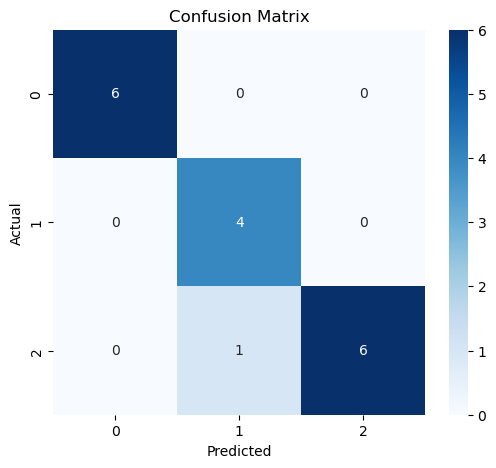

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Bagging Classifier

Bagging (Bootstrap Aggregating) is an ensemble learning technique that trains multiple models independently on different random samples of the training data and combines their predictions.

In [41]:

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.9411764705882353



#Boosting (AdaBoost)

Boosting is an ensemble learning technique where models are trained sequentially. Each new model focuses on correcting the mistakes made by the previous model.

In [42]:
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boost.fit(X_train, y_train)

boost_pred = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))


Boosting Accuracy: 0.9411764705882353


#Model Comparison

Compare the accuracy of Random Forest, Bagging, and Boosting models.

In [43]:
rf_accuracy = accuracy_score(y_test, y_pred)

bag_accuracy = accuracy_score(y_test, bag_pred)

boost_accuracy = accuracy_score(y_test, boost_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "Boosting"],
    "Accuracy": [rf_accuracy, bag_accuracy, boost_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.941176
1,Bagging,0.941176
2,Boosting,0.941176


The Random Forest, Bagging, and Boosting models achieved similar accuracy on the Glass dataset. Since the dataset is relatively small, all three models learned similar decision boundaries and showed comparable performance.

1. Explain Bagging and Boosting methods. How are they different?

Bagging (Bootstrap Aggregating):

Bagging is an ensemble learning method.
It trains multiple models on different random samples of the dataset.
All models work independently.
The final prediction is made by combining all model outputs (majority voting for classification, averaging for regression).
It helps reduce variance and prevents overfitting.

Example: Random Forest.

Boosting:

Boosting is also an ensemble learning method.
Models are trained one after another (sequentially).
Each new model focuses on correcting the mistakes made by the previous model.
The final prediction is a weighted combination of all models.
It helps reduce bias and improves accuracy.

Examples: AdaBoost, Gradient Boosting, XGBoost.
    
2. Explain how to handle imbalance in the data.
    Imbalanced data means one class has significantly more samples than another. To handle it, we can use oversampling (like SMOTE), undersampling, class weights, collect more minority data, and evaluate the model using Precision, Recall, F1-Score, and ROC-AUC instead of relying only on accuracy.